In [10]:
import os
from bs4 import BeautifulSoup
import time
from urllib.request import urlopen
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import array
import numpy as np
import logging
import requests
from requests.exceptions import RequestException
import send2trash
import re
import certifi
import io
from io import StringIO
from fuzzywuzzy import process
from tabulate import tabulate
import ssl
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.chrome.service import Service
from webdriver_manager.chrome import ChromeDriverManager
from scipy.stats import pearsonr
import statsmodels.api as sm
pd.set_option('display.max_columns', None)
from nba_api.stats.static import players
from nba_api.stats.endpoints import leagueleaders
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import itertools
from sklearn.model_selection import train_test_split, GridSearchCV


In [11]:
years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

for i, year in enumerate(years):
    year = str(year)
    if i != len(years) - 1:
        next_year = str(years[i + 1])
        years[i] = str(year) + "-" + next_year[2:]

years = years[0:9]

seas_ids = ['22015', '22016', '22017', '22018', '22019', '22020', '22021', '22022', '22023', '22024']

years

['2015-16',
 '2016-17',
 '2017-18',
 '2018-19',
 '2019-20',
 '2020-21',
 '2021-22',
 '2022-23',
 '2023-24']

In [12]:
# Isolating player stats

df = pd.read_csv("all_seasons_df_try2.csv")
stats = df.columns.tolist()
# stats = stats[22:]
stats = stats[69:]
stats

['CUT_POSS',
 'CUT_PTS',
 'HANDOFF_POSS',
 'HANDOFF_PTS',
 'ISOLATION_POSS',
 'ISOLATION_PTS',
 'OFFSCREEN_POSS',
 'OFFSCREEN_PTS',
 'POSTUP_POSS',
 'POSTUP_PTS',
 'PRBALLHANDLER_POSS',
 'PRBALLHANDLER_PTS',
 'PRROLLMAN_POSS',
 'PRROLLMAN_PTS',
 'OFFREBOUND_POSS',
 'OFFREBOUND_PTS',
 'SPOTUP_POSS',
 'SPOTUP_PTS',
 'TRANSITION_POSS',
 'TRANSITION_PTS']

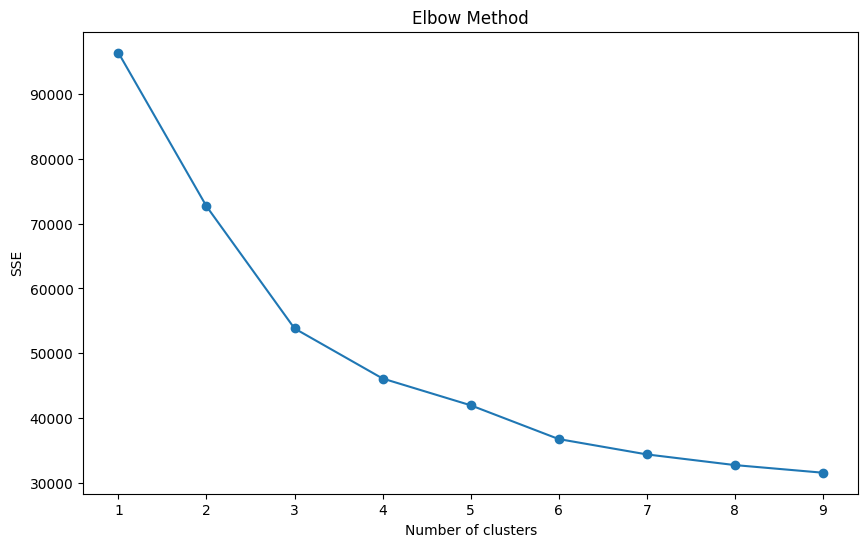

Test MSE: 36.711609574317805


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# df = pd.read_csv("all_seasons_df_try2.csv")
df = pd.read_csv("all_seasons_df_try2.csv")

# Selecting features:
# features = df.drop(columns=['PLAYER_ID', 'PLAYER', 'TEAM', 'GP', 'FGM', 'FG3M', 'FTM', 'FTA', 'OREB', 'DREB', 'REB', 'AST', 'PTS', 'Season ID', 'PTS_GAME', 'MIN', 'POSS', 'PIE', 'Passes', 'Asst_Pts_Cr', 'Drive_Ast_Ast', 'Elbow_Asst_Asst', 'Post_Asst_Asst', 'Paint_Asst_Asst', 'Drive_Pass_Pass', 'Elbow_Pass_Pass', 'Post_Pass_Pass', 'Paint_Pass_Pass', 'Drib_Touch', 'Sec_Touch']).columns
features = stats

# Normalize the data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)

# Apply PCA with the maximum number of components
pca = PCA(n_components=len(features))  # Use all components
df_pca = pd.DataFrame(pca.fit_transform(df_scaled), columns=[f'PC{i+1}' for i in range(len(features))])

# Determine optimal number of clusters using Elbow Method
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 10), sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method')
plt.show()

# Choose an optimal number of clusters (e.g., k=3)
clusters = 9
kmeans = KMeans(n_clusters = clusters, random_state = 42)
df['Cluster'] = kmeans.fit_predict(df_pca)

# # Display clustered data
df[['PLAYER', 'Cluster']]
df.to_csv(f"all_seasons_df_{clusters}.csv", index = False)

for year in years:
    df = pd.read_csv(f"{year}/{year}_all_players_try2.csv")
    df['Cluster'] = None
    df.to_csv(f"{year}/{year}_all_players_try2.csv", index = False)

all_seasons_df = pd.read_csv("all_seasons_df_9.csv")

for i, year in enumerate(years):
    season_df = pd.read_csv(f"{year}/{year}_all_players_try2.csv")
    season_id = int(seas_ids[i])
    
    relevant_rows = all_seasons_df[all_seasons_df['Season ID'] == int(season_id)]

    for i in range(len(relevant_rows)):
        player_name = relevant_rows.iloc[i]['PLAYER']
        player_cluster = relevant_rows.iloc[i]['Cluster']
        season_df.loc[season_df['PLAYER'] == player_name, 'Cluster'] = player_cluster

    # Save the updated season DataFrame back to the CSV file
    season_df.to_csv(f"{year}/{year}_all_players_try2.csv", index=False)

# Attaches player cluster and player pie to each player in the lineup

for i, year in enumerate(years):
    df = pd.read_csv(f"{year}/{year}_lineups.csv")

    all_players_df = pd.read_csv(f"{year}/{year}_all_players_try2.csv")

    players_ids = all_players_df['PLAYER_ID'].tolist()
    players_pie = all_players_df['PIE'].tolist()

    for j in range(len(players_ids)):
        players_ids[j] = str(players_ids[j])
    players_clusters = all_players_df['Cluster'].tolist()

    for w in range(len(df)):
        group_ids = str(df.loc[w, 'GROUP_ID'])
        cleaned_string = group_ids.strip('-')
        integer_strings = cleaned_string.split('-')

        cluster_0 = 0
        cluster_1 = 0
        cluster_2 = 0
        cluster_3 = 0
        cluster_4 = 0
        cluster_5 = 0
        cluster_6 = 0
        cluster_7 = 0
        cluster_8 = 0

        for j, strings in enumerate(integer_strings):
            player_index = players_ids.index(strings)
            player_cluster = players_clusters[player_index]
            player_pie = players_pie[player_index]
            if player_cluster == 0:
                cluster_0 += 1
            if player_cluster == 1:
                cluster_1 += 1
            if player_cluster == 2:
                cluster_2 += 1
            if player_cluster == 3:
                cluster_3 += 1
            if player_cluster == 4:
                cluster_4 += 1
            if player_cluster == 5:
                cluster_5 += 1
            if player_cluster == 6:
                cluster_6 += 1
            if player_cluster == 7:
                cluster_7 += 1
            if player_cluster == 8:
                cluster_8 += 1
            # df.loc[w, f'PLAYER_{j}_Cluster'] = player_cluster
            # df.loc[w, f'PLAYER_{j}_PIE'] = player_pie
        
        df.loc[w, "Cluster_0"] = cluster_0
        df.loc[w, "Cluster_1"] = cluster_1
        df.loc[w, "Cluster_2"] = cluster_2
        df.loc[w, "Cluster_3"] = cluster_3
        df.loc[w, "Cluster_4"] = cluster_4
        df.loc[w, "Cluster_5"] = cluster_5
        df.loc[w, "Cluster_6"] = cluster_6
        df.loc[w, "Cluster_7"] = cluster_7
        df.loc[w, "Cluster_8"] = cluster_8
    df.to_csv(f"{year}/{year}_lineups.csv", index = False)

# Combining all lineup dfs into one lineup df

lineup_dfs = []

for year in years:
    df = pd.read_csv(f"{year}/{year}_lineups.csv")
    lineup_dfs.append(df)

lineup_df = pd.concat(lineup_dfs, axis = 0)
lineup_df.reset_index(drop=True, inplace=True)

lineup_df = lineup_df.sort_values(by='R', ascending=False)

# lineup_df.to_csv("all_lineups_2.csv", index = False)
lineup_df.to_csv("all_lineups_2.csv", index = False)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Sample DataFrame (replace with your actual data)
df = pd.read_csv("all_lineups_2.csv")

features = ['MIN', 'POSS', 'Cluster_0', 'Cluster_1', 'Cluster_2', 'Cluster_3', 'Cluster_4', 'Cluster_5', 'Cluster_6', 'Cluster_7', 'Cluster_8']
target_column = 'R'

# Separate features and target variable
X = df[features]
y = df[target_column]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the model
model = RandomForestRegressor(random_state=42)

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate mean squared error (MSE)
test_mse = mean_squared_error(y_test, y_pred)

# Output the MSE value
print(f"Test MSE: {test_mse}")

In [9]:
# Random Forest- THIS IS THE FINAL ONE WITH SCALED DATA

df = pd.read_csv("all_lineups_2.csv")

# Separate features and target variable
X = df[features]
y = df[target_column]

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the model
model = RandomForestRegressor(random_state=42)

# Define the grid of hyperparameters to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Set up the grid search
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the grid search to the data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters
print("Best hyperparameters: ", grid_search.best_params_)

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
test_mse = mean_squared_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# Asking model for most and least efficient lineups

best_model.fit(X_train, y_train)

# Keeping minutes and possessions constant
min = 100000000
poss = 100000000

# Finding all possible five man lineup combinations
num_clusters = 9
combinations = [comb for comb in itertools.product(range(6), repeat=num_clusters) if sum(comb) == 5]
combinations_df = pd.DataFrame(combinations, columns=[f'cluster_{i}' for i in range(num_clusters)])

# Add constans to df
combinations_df['MIN'] = min
combinations_df['POSS'] = poss

# Predicting efficiency
predictions = best_model.predict(combinations_df)

# Add the predictions to the DataFrame
combinations_df['Predicted_Net_Rating'] = predictions

# Find most and least efficient lineups
most_efficient = combinations_df.loc[combinations_df['Predicted_Net_Rating'].idxmax()]
least_efficient = combinations_df.loc[combinations_df['Predicted_Net_Rating'].idxmin()]

combinations_df = combinations_df.sort_values(by='Predicted_Net_Rating', ascending=False)
combinations_df.to_csv("Lineup_Efficiency_4.csv", index = False)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.7s
[CV] END m

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
